In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import json
import glob
import os
import re
from collections import Counter
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

sns.set_style('whitegrid')
%matplotlib inline

[nltk_data] Downloading package wordnet to /Users/adrien.schurger-
[nltk_data]     foy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/adrien.schurger-
[nltk_data]     foy/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/adrien.schurger-
[nltk_data]     foy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
def load_dota2_data():
    base_path = "../data/dota2/labeled/"
    files = glob.glob(os.path.join(base_path, "*_labels.csv"))
    dfs = []
    for f in files:
        df = pd.read_csv(f)
        df['filename'] = os.path.basename(f)
        dfs.append(df)

    data = pd.concat(dfs, ignore_index=True)

    # Clean labels: 'x' -> 1, NaN -> 0
    data['is_toxic'] = data['label'].apply(lambda x: 1 if str(x).strip().lower() in ['x', 'c'] else 0)

    # Fill NaN messages
    data['message'] = data['message'].fillna('')

    return data

dota_df = load_dota2_data()
print(f"Total messages: {len(dota_df)}")
print(f"Columns: {dota_df.columns.tolist()}")
dota_df.head()

Total messages: 8968
Columns: ['Unnamed: 0', 'message', 'label', 'player', 'special_token_message', 'match', 'filename', 'time', 'user_id', 'Unnamed: 0.1', 'is_toxic']


,Unnamed: 0,message,label,player,special_token_message,match,filename,time,user_id,Unnamed: 0.1,is_toxic
0,0.0,репорт инвока,NaN,1,[Team0][Player1]: репорт инвока,41,train_labels.csv,NaN,NaN,NaN,0
1,1.0,фидит курой,NaN,1,[Team0][Player1]: фидит курой,41,train_labels.csv,NaN,NaN,NaN,0
2,2.0,+ слил мид,NaN,1,[Team0][Player1]: + слил мид,41,train_labels.csv,NaN,NaN,NaN,0
3,3.0,Ez mid,NaN,1,[Team0][Player1]: Ez mid,41,train_labels.csv,NaN,NaN,NaN,0
4,4.0,пидор,NaN,7,[Team1][Player2]: пидор,41,train_labels.csv,NaN,NaN,NaN,0


In [3]:
def load_guidelines():
    try:
        with open("../data/platform_guidelines.json", "r") as f:
            guidelines = json.load(f)
        return guidelines
    except FileNotFoundError:
        print("Guidelines file not found.")
        return {}

guidelines = load_guidelines()
print(f"Loaded guidelines for {len(guidelines)} platforms: {list(guidelines.keys())}")

Loaded guidelines for 11 platforms: ['Xbox', 'PlayStation Network (PSN)', 'VALORANT (Riot Games)', 'Steam (Valve)', 'YouTube', 'Twitch', 'Discord', 'Snapchat', 'TikTok', 'Reddit', 'X (formerly Twitter)']


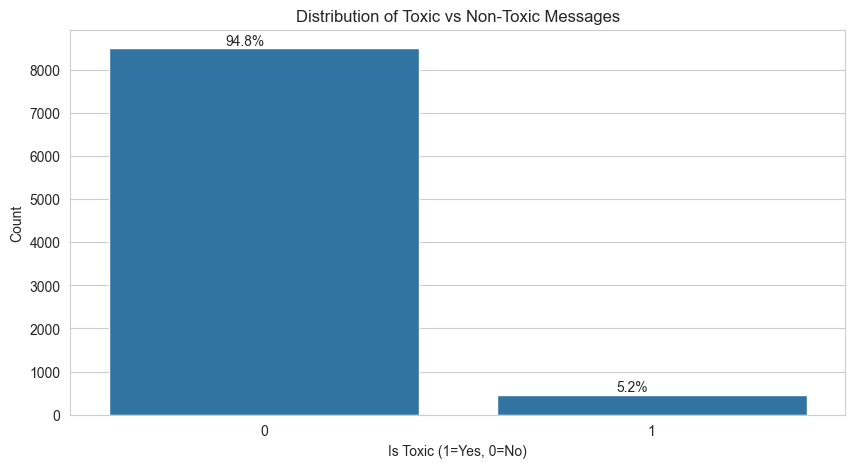

is_toxic
0    0.948149
1    0.051851
Name: proportion, dtype: float64


In [4]:
# Class Imbalance
if not dota_df.empty:
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(x='is_toxic', data=dota_df)
    plt.title('Distribution of Toxic vs Non-Toxic Messages')
    plt.xlabel('Is Toxic (1=Yes, 0=No)')
    plt.ylabel('Count')

    # Add percentages
    total = len(dota_df)
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height()/total)
        x = p.get_x() + p.get_width() / 2 - 0.05
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom')

    plt.show()

    print(dota_df['is_toxic'].value_counts(normalize=True))

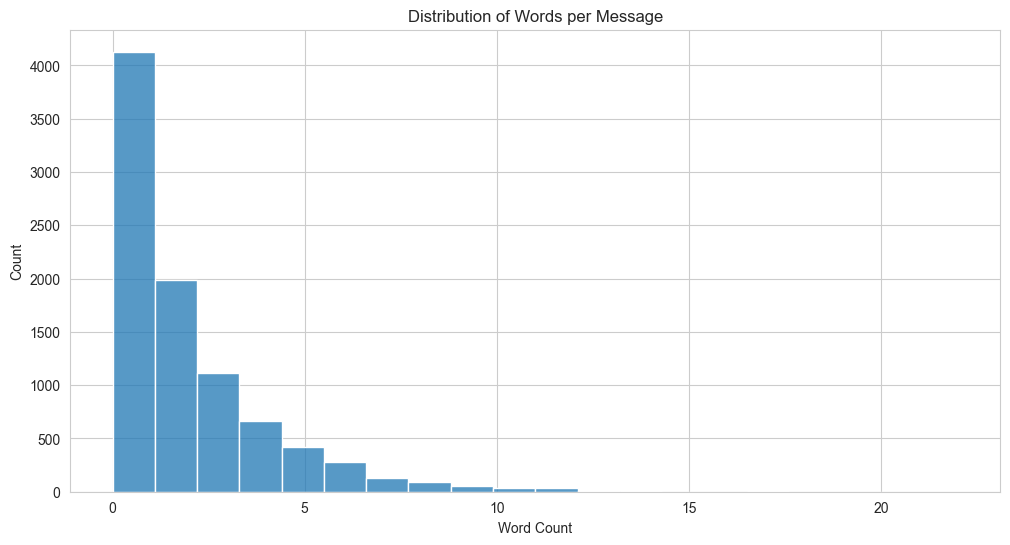

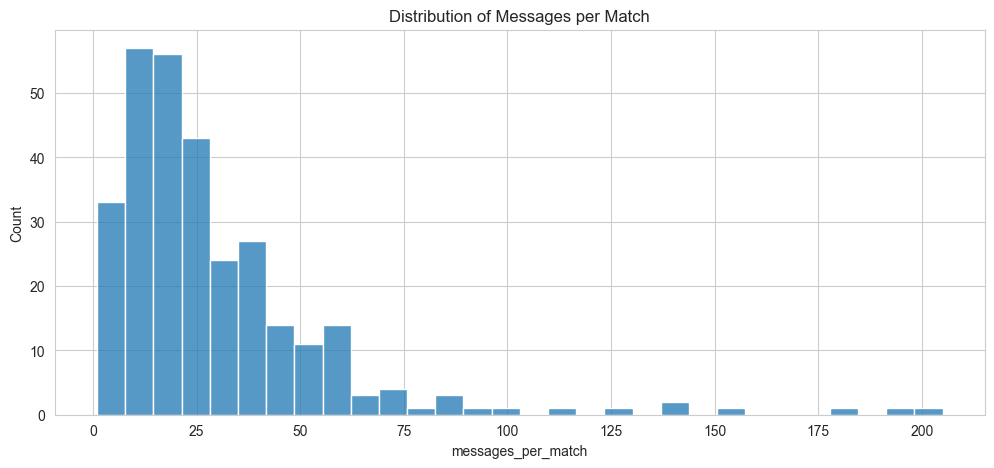

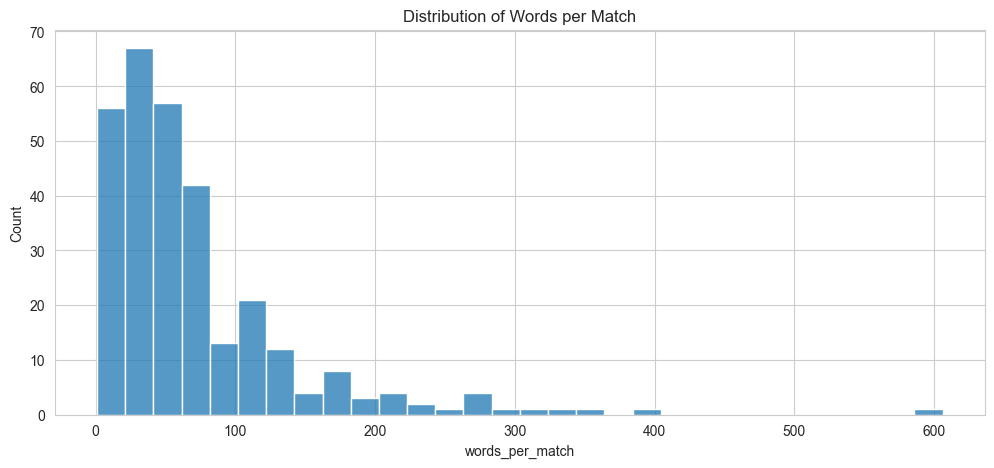

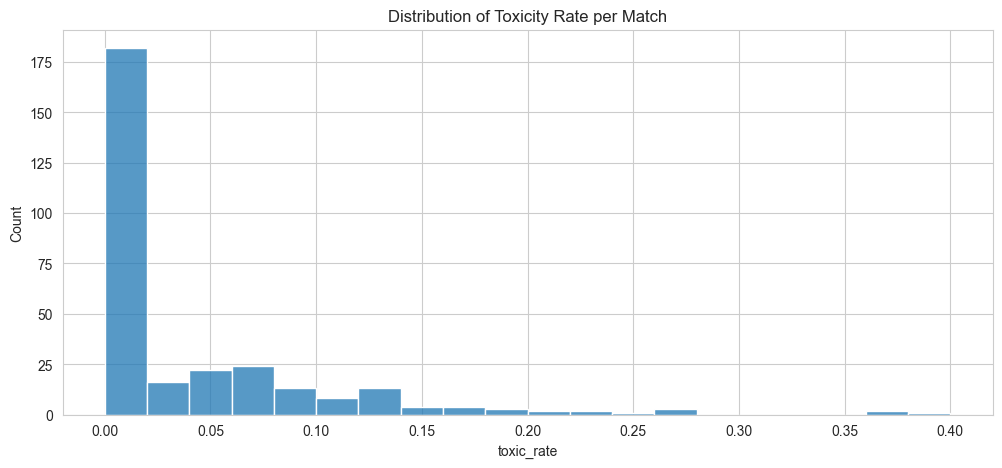

In [5]:
# Text Stats & Distributions
if not dota_df.empty:
    # Add word count
    dota_df['word_count'] = dota_df['message'].apply(lambda x: len(str(x).split()))

    # Words per message (Toxic vs Non-Toxic)
    plt.figure(figsize=(12, 6))
    sns.histplot(data=dota_df, x='word_count', bins=20)
    plt.title('Distribution of Words per Message')
    plt.xlabel('Word Count')
    plt.show()

    # Aggregating by Match
    if 'match' in dota_df.columns:
        match_stats = dota_df.groupby('match').agg({
            'message': 'count',
            'word_count': 'sum',
            'is_toxic': 'sum'
        }).rename(columns={'message': 'messages_per_match', 'word_count': 'words_per_match', 'is_toxic': 'toxic_messages_per_match'})

        # Messages per match
        plt.figure(figsize=(12, 5))
        sns.histplot(match_stats['messages_per_match'], bins=30)
        plt.title('Distribution of Messages per Match')
        plt.show()

        # Words per match
        plt.figure(figsize=(12, 5))
        sns.histplot(match_stats['words_per_match'], bins=30)
        plt.title('Distribution of Words per Match')
        plt.show()

        # Toxic % per match
        match_stats['toxic_rate'] = match_stats['toxic_messages_per_match'] / match_stats['messages_per_match']
        plt.figure(figsize=(12, 5))
        sns.histplot(match_stats['toxic_rate'], bins=20)
        plt.title('Distribution of Toxicity Rate per Match')
        plt.show()
    else:
        print("Match column not found")

Max active players observed in a match: 10


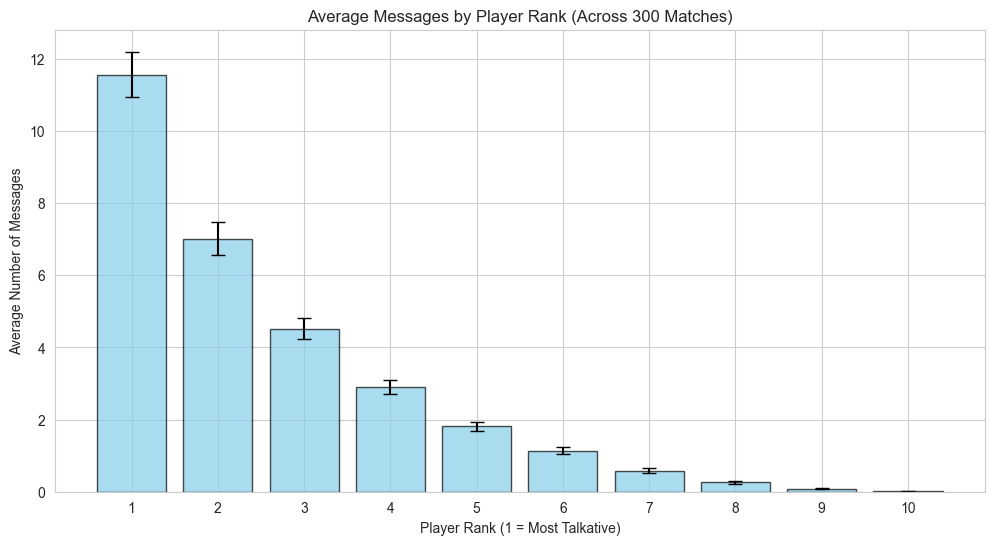

Rank 1: Mean=11.57, SEM=0.63
Rank 2: Mean=7.01, SEM=0.45
Rank 3: Mean=4.52, SEM=0.28
Rank 4: Mean=2.90, SEM=0.19
Rank 5: Mean=1.81, SEM=0.12
Rank 6: Mean=1.14, SEM=0.09
Rank 7: Mean=0.59, SEM=0.06
Rank 8: Mean=0.26, SEM=0.03
Rank 9: Mean=0.08, SEM=0.02
Rank 10: Mean=0.01, SEM=0.01


In [6]:
# Player Message Distribution (Ranked)
if not dota_df.empty and 'match' in dota_df.columns and 'player' in dota_df.columns:
    # Count messages per player per match
    player_counts = dota_df.groupby(['match', 'player']).size().reset_index(name='msg_count')

    # For each match, rank players by msg_count (descending)
    ranks_list = []
    
    # Iterate over each match
    for match_id, group in player_counts.groupby('match'):
        # Get counts, sort descending
        counts = group['msg_count'].sort_values(ascending=False).values
        ranks_list.append(counts)

    # Determine max distinctive players in any match
    max_players = max(len(r) for r in ranks_list) if ranks_list else 0
    print(f"Max active players observed in a match: {max_players}")

    # Create a matrix (matches x max_players). Pad with NaN or 0?
    # If a player isn't in the list, they had 0 messages.
    # We should average the "1st most talkative", "2nd most talkative", etc.
    # NOTE: If a match has 5 players talking, rank 6-10 are 0.
    
    # Let's assume there are always 10 players potentially (slots 0-9).
    # If only 5 speak, the other 5 have 0 messages.
    # So we should pad with 0s up to 10.
    
    NUM_PLAYERS_PER_MATCH = 10
    
    padded_ranks = []
    for r in ranks_list:
        # Pad with zeros
        padded = np.zeros(NUM_PLAYERS_PER_MATCH)
        length = min(len(r), NUM_PLAYERS_PER_MATCH)
        padded[:length] = r[:length]
        padded_ranks.append(padded)
        
    rank_matrix = np.array(padded_ranks)
    
    # Calculate Mean and Standard Error
    means = np.mean(rank_matrix, axis=0)
    sems = np.std(rank_matrix, axis=0) / np.sqrt(len(rank_matrix))
    
    # Visualization
    plt.figure(figsize=(12, 6))
    x = np.arange(1, NUM_PLAYERS_PER_MATCH + 1)
    
    plt.bar(x, means, yerr=sems, capsize=5, alpha=0.7, color='skyblue', edgecolor='black')
    
    plt.title(f'Average Messages by Player Rank (Across {len(rank_matrix)} Matches)')
    plt.xlabel('Player Rank (1 = Most Talkative)')
    plt.ylabel('Average Number of Messages')
    plt.xticks(x)
    
    plt.show()
    
    # Print values
    for i, (m, s) in enumerate(zip(means, sems)):
        print(f"Rank {i+1}: Mean={m:.2f}, SEM={s:.2f}")

else:
    print("Cannot perform player rank analysis (missing data/columns)")

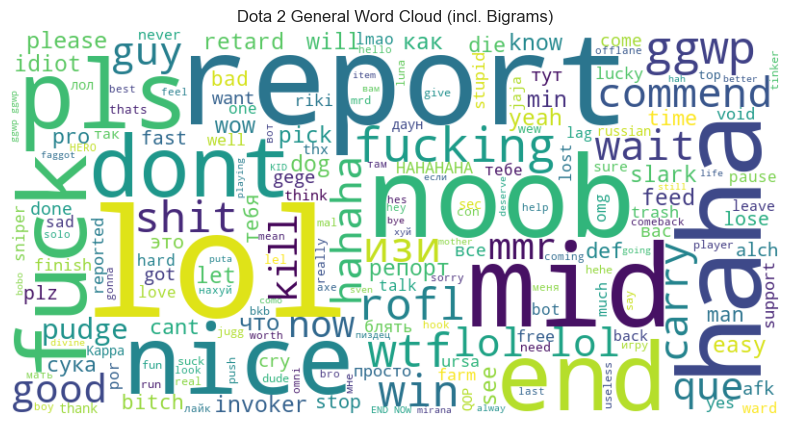

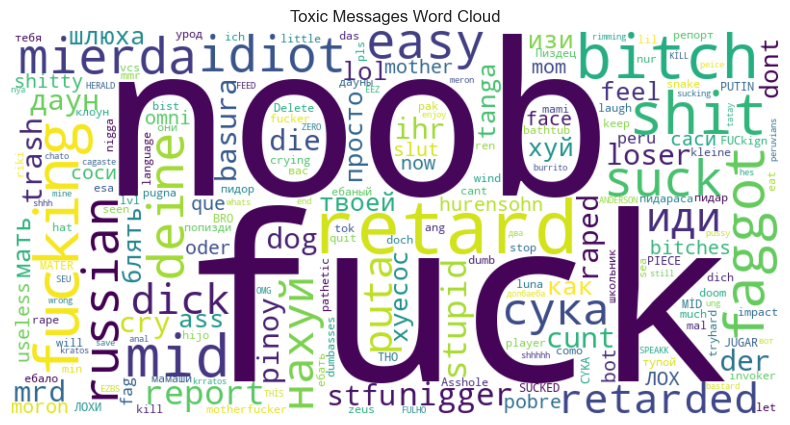

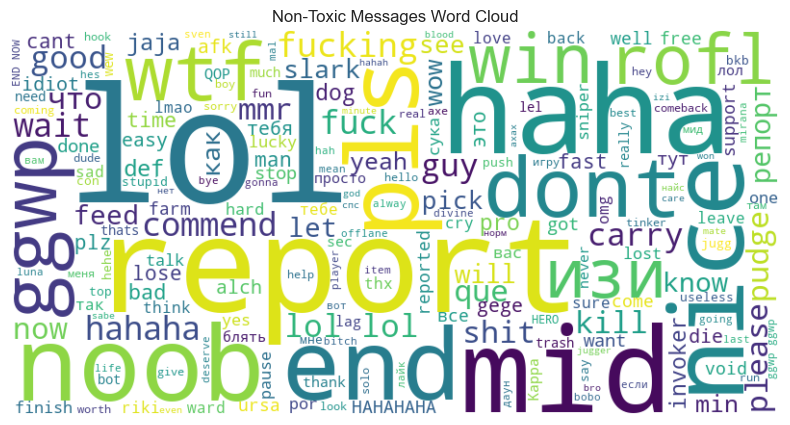

In [7]:
# Wordclouds (with Bigrams)
stopwords = set(STOPWORDS)
stopwords.update(["gg", "wp", "ez", "game", "match", "team", "play", "dota", "u"])

def plot_wordcloud(text, title):
    # collocations=True enables bigrams by default in WordCloud
    if not text.strip():
        print(f"No text for {title}")
        return
    wc = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords, collocations=True, min_word_length=3).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

if not dota_df.empty:
    # General
    all_text = " ".join(dota_df['message'].astype(str))
    plot_wordcloud(all_text, "Dota 2 General Word Cloud (incl. Bigrams)")

    # Toxic
    toxic_text = " ".join(dota_df[dota_df['is_toxic'] == 1]['message'].astype(str))
    plot_wordcloud(toxic_text, "Toxic Messages Word Cloud")

    # Non-Toxic
    nontoxic_text = " ".join(dota_df[dota_df['is_toxic'] == 0]['message'].astype(str))
    plot_wordcloud(nontoxic_text, "Non-Toxic Messages Word Cloud")

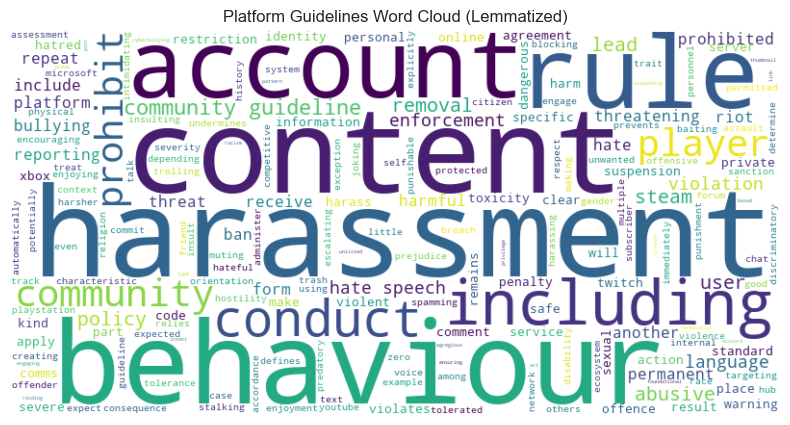

Most common lemmatized words in guidelines:
[('harassment', 14), ('content', 13), ('community', 12), ('behaviour', 12), ('rule', 9), ('account', 8), ('including', 8), ('hate', 7), ('conduct', 7), ('guideline', 7), ('player', 6), ('user', 5), ('abusive', 5), ('policy', 5), ('prohibit', 5), ('steam', 5), ('lead', 5), ('removal', 5), ('language', 4), ('enforcement', 4), ('speech', 4), ('violation', 4), ('bullying', 3), ('threatening', 3), ('prohibited', 3), ('another', 3), ('reporting', 3), ('form', 3), ('platform', 3), ('receive', 3), ('permanent', 3), ('repeat', 3), ('riot', 3), ('threat', 3), ('ban', 3), ('harmful', 3), ('xbox', 2), ('standard', 2), ('make', 2), ('clear', 2), ('hatred', 2), ('place', 2), ('service', 2), ('include', 2), ('harm', 2), ('harass', 2), ('identity', 2), ('personal', 2), ('action', 2), ('agreement', 2), ('code', 2), ('specific', 2), ('sexual', 2), ('suspension', 2), ('comms', 2), ('toxicity', 2), ('penalty', 2), ('warning', 2), ('restriction', 2), ('severe', 2

In [8]:
# Platform Guidelines Analysis - Wordcloud
if guidelines:
    lemmatizer = WordNetLemmatizer()
    
    # Combine texts
    guidelines_text = ""
    for platform, data in guidelines.items():
        excerpt = data.get('excerpt', '')
        guidelines_text += " " + excerpt

    # Lemmatize the text
    # 1. Tokenize (simple split by non-word chars)
    tokens = re.findall(r'\w+', guidelines_text.lower())
    
    # 2. Filter stopwords and short words, then lemmatize
    lemmatized_tokens = [
        lemmatizer.lemmatize(word) 
        for word in tokens 
        if word not in stopwords and len(word) > 3
    ]
    
    # 3. Join back for wordcloud
    lemmatized_text = " ".join(lemmatized_tokens)

    # Plot Lemmatized Wordcloud
    plot_wordcloud(lemmatized_text, "Platform Guidelines Word Cloud (Lemmatized)")

    # Print top lemmatized words
    common_lemmatized_counter = Counter(lemmatized_tokens)
    print("Most common lemmatized words in guidelines:")
    print(common_lemmatized_counter.most_common())

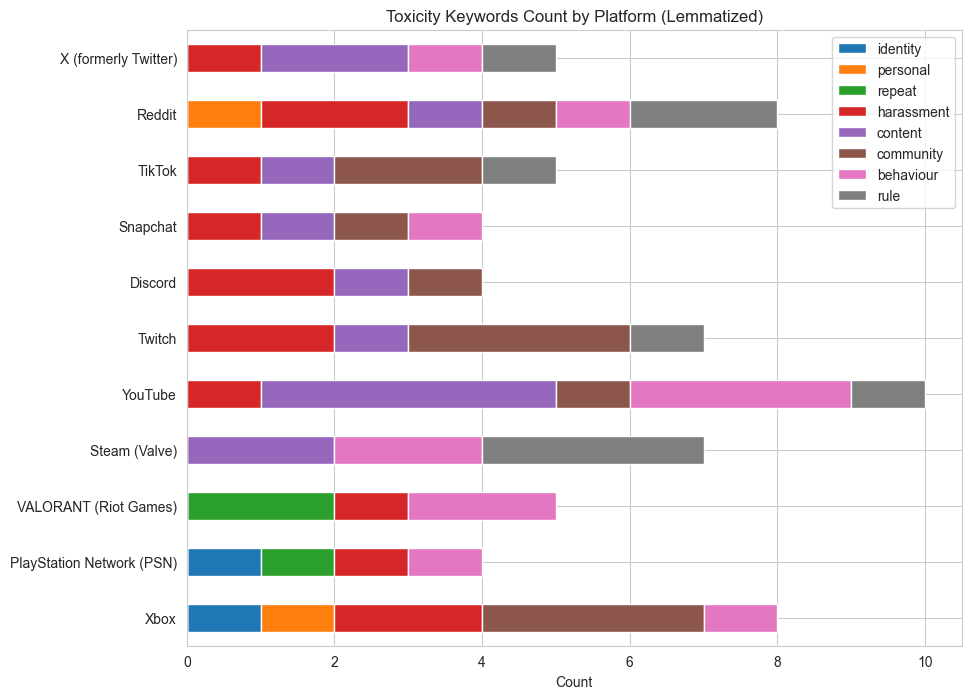

In [9]:
# Platform Guidelines Analysis - Keywords & Heatmap
if guidelines:
    # Specific keywords of interest + top 5
    # Use only unique keywords
    keywords = ['identity', 'personal', 'repeat'] + [e[0] for e in common_lemmatized_counter.most_common(5)]
    keywords = list(dict.fromkeys(keywords))
    
    # Build matrix for counts
    platforms = list(guidelines.keys())
    data_matrix = []
    
    lemmatizer = WordNetLemmatizer()
    
    for p in platforms:
        text = guidelines[p].get('excerpt', '').lower()
        # Tokenize and Lemmatize
        tokens = re.findall(r'\w+', text)
        lemmas = [lemmatizer.lemmatize(t) for t in tokens]
        
        row = []
        for k in keywords:
            # Count exact matches of the lemma
            count = lemmas.count(k)
            row.append(count)
        data_matrix.append(row)

    # Plot Bar Chart
    if data_matrix:
        df_keywords = pd.DataFrame(data_matrix, columns=keywords, index=platforms)
        
        # Plot as grouped bar chart
        df_keywords.plot(kind='barh', stacked=True, figsize=(10, 8))
        plt.title("Toxicity Keywords Count by Platform (Lemmatized)")
        plt.xlabel("Count")
        plt.show()